### Sanity Checks

#### Events Sub 01

In [1]:
import pandas as pd
from pathlib import Path

tsv_dir = Path('../MNE-sample-data/ds006761/sub-01')
tsv_file = next(tsv_dir.glob('**/*.tsv'), None)

print(tsv_file)

df = pd.read_csv(tsv_file, sep='\t')
df.head()

..\MNE-sample-data\ds006761\sub-01\eeg\sub-01_task-RPS_events.tsv


,onset,duration,onset_sample,trial_num,player1_resp,player1_rt,player2_resp,player2_rt,outcome
0,32.777344,5,67128,1,3,0.558,2,0.516,2
1,37.769043,5,77351,2,3,0.435,3,0.560,1
2,42.760742,5,87574,3,2,0.643,2,0.451,1
3,47.760254,5,97813,4,2,0.717,2,0.459,1
4,52.760254,5,108053,5,1,0.642,3,0.359,2


#### 02-Filter

Opening raw data file ../data/sub-01_P1_raw.fif...
    Range : 0 ... 7514111 =      0.000 ...  3669.000 secs
Ready.
Reading 0 ... 7514111  =      0.000 ...  3669.000 secs...
Opening raw data file ../data/sub-01_P1_filtered.fif...


C:\Users\hugoh\OneDrive\01 - Studium\MSc\00 - Module\SpaAohbp\eeg-bala-sharks\eeg_pipeline\utils.py:10: RuntimeWarning: This filename (../data/sub-01_P1_filtered.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(filename, preload=preload)


    Range : 0 ... 7514111 =      0.000 ...  3669.000 secs
Ready.
Reading 0 ... 7514111  =      0.000 ...  3669.000 secs...
Using matplotlib as 2D backend.


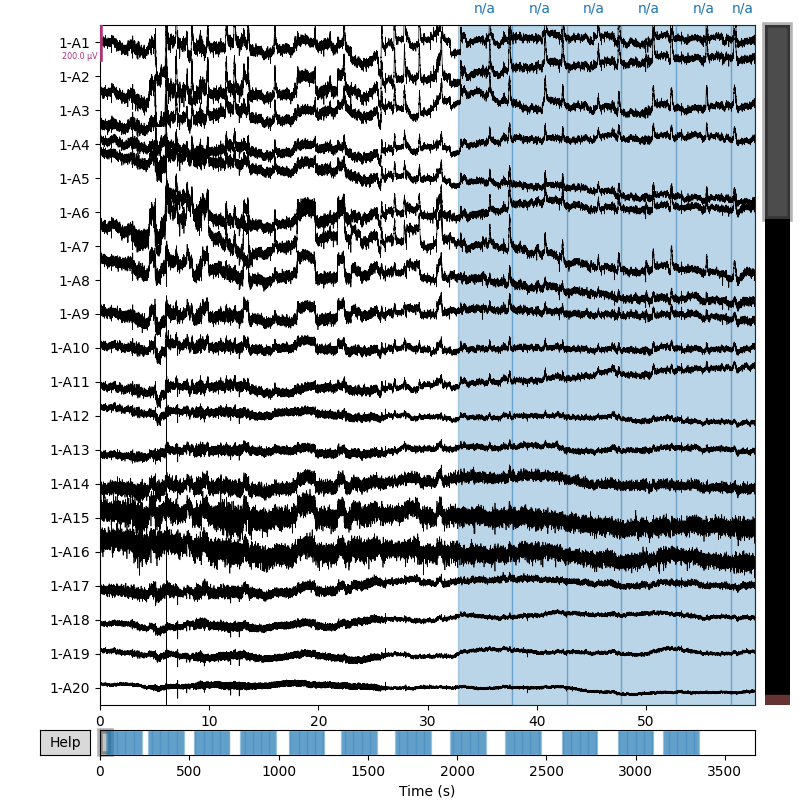

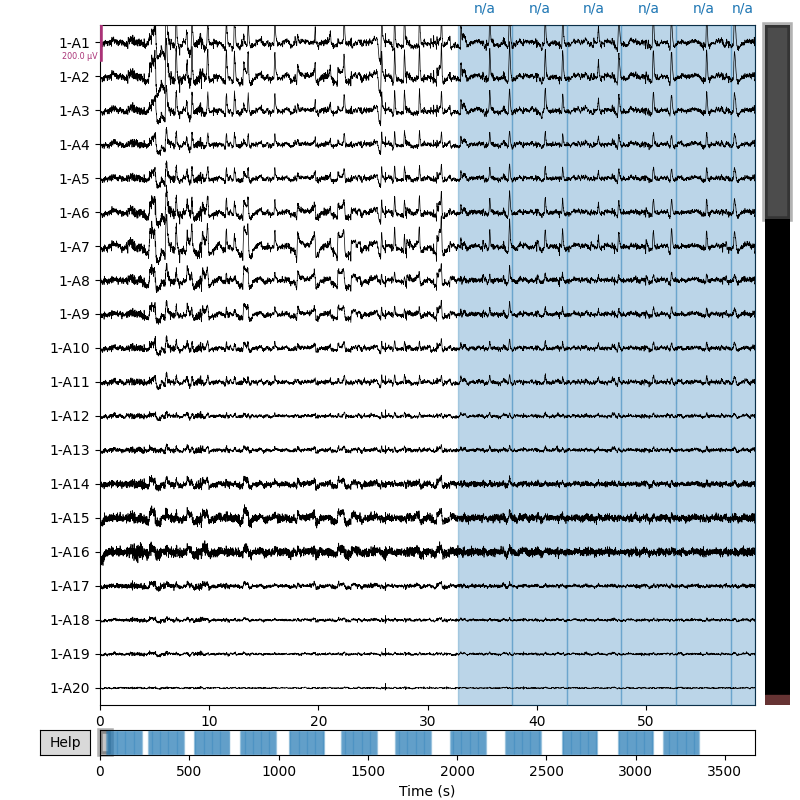

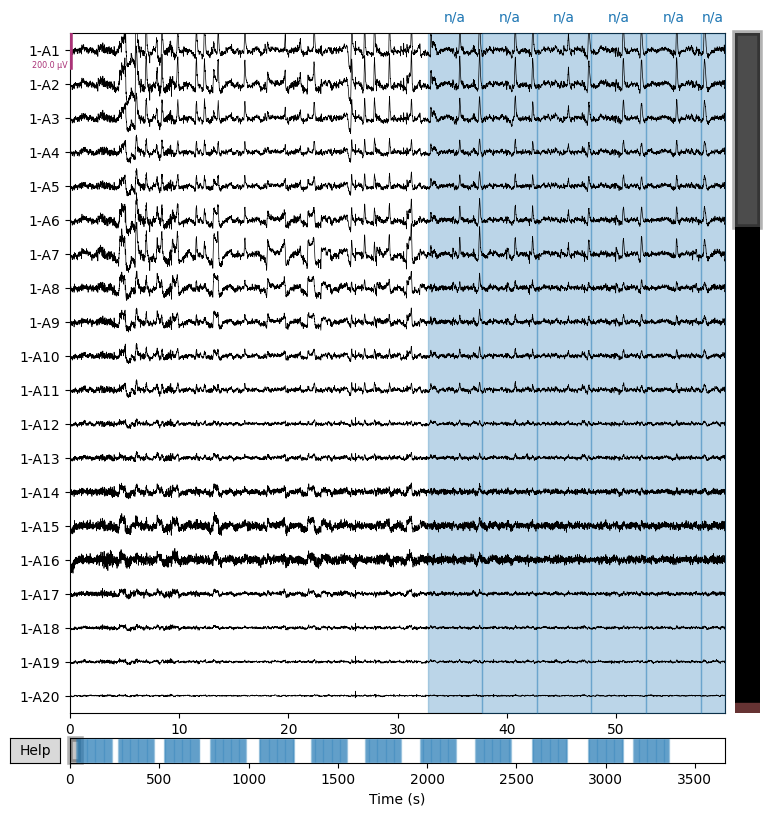

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str((Path.cwd() / '..' / 'eeg_pipeline').resolve()))
%matplotlib ipympl


import utils
from utils import load_raw

# --- Original Data ---
raw_orig = load_raw("../data/sub-01_P1_raw.fif")

# --- Filtered Data ---
raw_filtered = load_raw("../data/sub-01_P1_filtered.fif")

# --- Scaling: e.g. ±100 µV, same for all channels ---
scaling = 1000e-7  # Volt

# --- Originalplot ---
raw_orig.plot(duration=60, scalings={'eeg': scaling}, title="Original P1")

# --- Filtered Plot ---
raw_filtered.plot(duration=60, scalings={'eeg': scaling}, title="Filtered P1")

#### 04-Down-Sampling

Opening raw data file ../data/sub-01_P1_raw.fif...
    Range : 0 ... 7514111 =      0.000 ...  3669.000 secs
Ready.
Reading 0 ... 7514111  =      0.000 ...  3669.000 secs...
Opening raw data file ../data/sub-01_P1_downsampled.fif...


C:\Users\hugoh\OneDrive\01 - Studium\MSc\00 - Module\SpaAohbp\eeg-bala-sharks\eeg_pipeline\utils.py:10: RuntimeWarning: This filename (../data/sub-01_P1_downsampled.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(filename, preload=preload)


    Range : 0 ... 1878527 =      0.000 ...  3668.998 secs
Ready.
Reading 0 ... 1878527  =      0.000 ...  3668.998 secs...


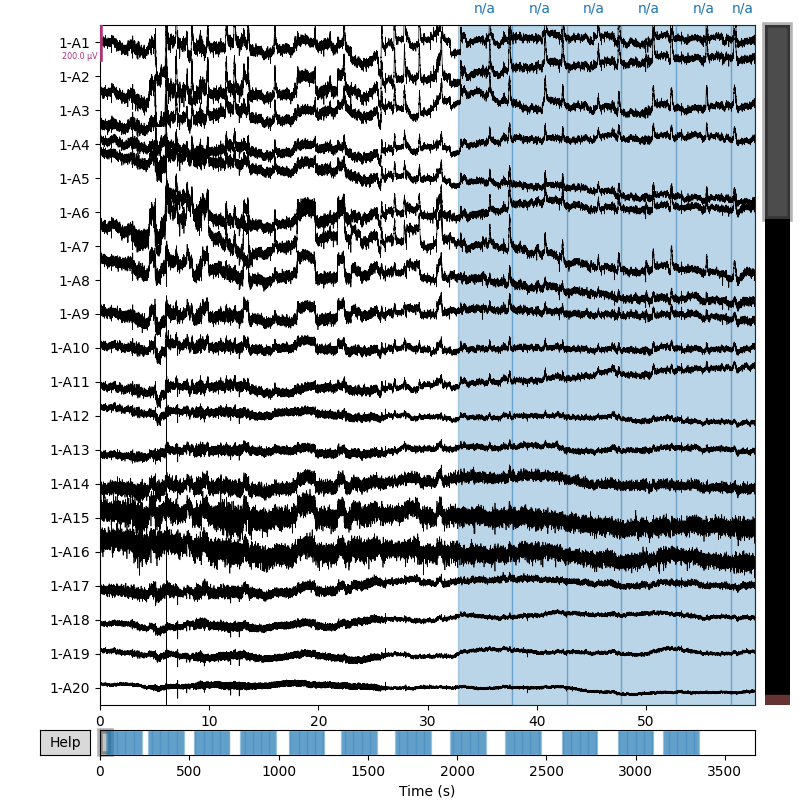

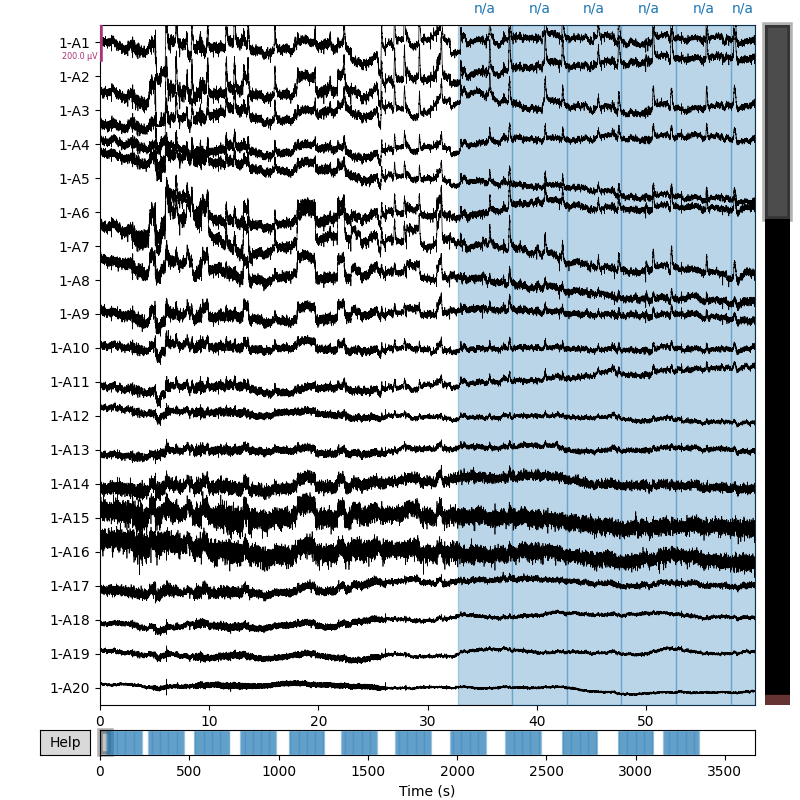

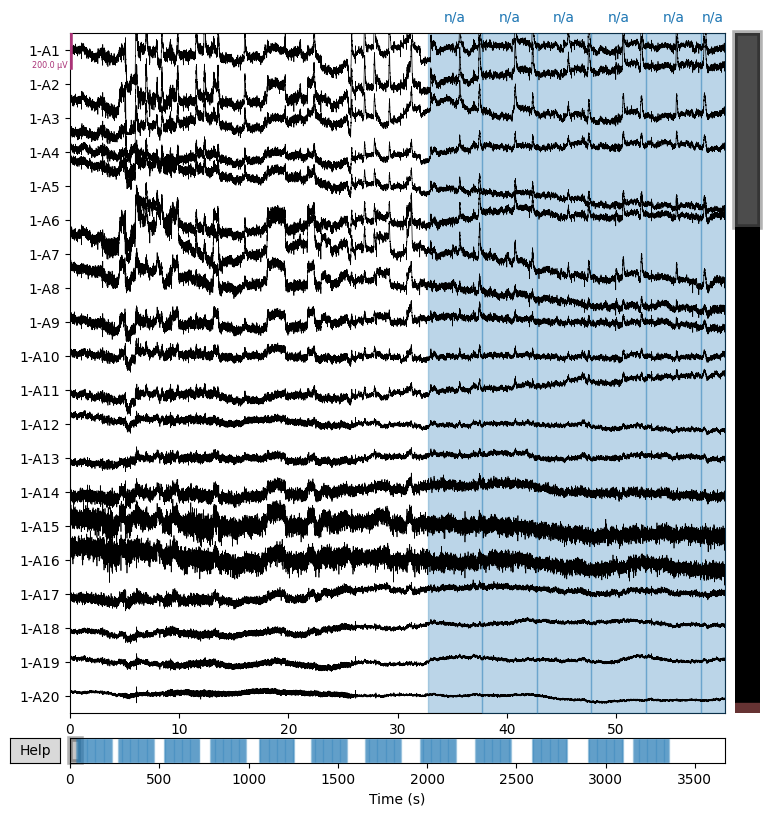

In [3]:
import sys
from pathlib import Path
sys.path.insert(0, str((Path.cwd() / '..' / 'eeg_pipeline').resolve()))
%matplotlib ipympl


import utils
from utils import load_raw

# --- Original Data ---
raw_orig = load_raw("../data/sub-01_P1_raw.fif")

# --- Filtered Data ---
raw_downsampled = load_raw("../data/sub-01_P1_downsampled.fif")

# --- Scaling: e.g. ±100 µV, same for all channels ---
scaling = 1000e-7  # Volt

# --- Originalplot ---
raw_orig.plot(duration=60, scalings={'eeg': scaling}, title="Original P1")

# --- Down-Sampled Plot ---
raw_downsampled.plot(duration=60, scalings={'eeg': scaling}, title="Down-Sampled P1")

#### 05 Epoching (without averaging)

Reading c:\Users\hugoh\OneDrive\01 - Studium\MSc\00 - Module\SpaAohbp\eeg-bala-sharks\sanity_checks\..\data\sub-01_P1_epoch.fif ...


C:\Users\hugoh\AppData\Local\Temp\ipykernel_712\4122458557.py:10: RuntimeWarning: This filename (../data/sub-01_P1_epoch.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs("../data/sub-01_P1_epoch.fif", preload=True)


    Found the data of interest:
        t =    -200.20 ...    5000.00 ms
        0 CTF compensation matrices available
Not setting metadata
480 matching events found
No baseline correction applied
0 projection items activated


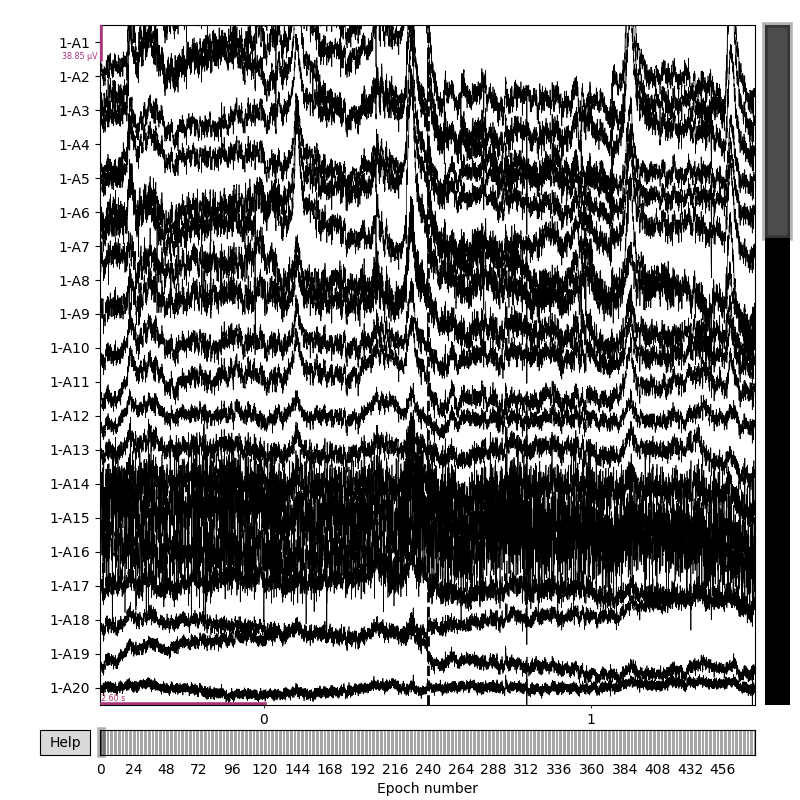

In [5]:
import sys
from pathlib import Path
sys.path.insert(0, str((Path.cwd() / '..' / 'eeg_pipeline').resolve()))
%matplotlib ipympl
import config

import mne

# --- Load Epochs ---
epochs = mne.read_epochs("../data/sub-01_P1_epoch.fif", preload=True)

# --- Plot all epochs for overview ---
fig = epochs.plot(scalings='auto', n_epochs=2, title="Epochs P1")

# Add time markers
# Halbtransparente rote Box von 0 bis 1 Sekunde
ax = fig.axes[0] 
for n in range(len(epochs.selection)):
    begin = n*(config.EPOCH_TMAX - config.EPOCH_TMIN) - config.EPOCH_TMIN
    ax.axvspan(begin, begin+2, color='orange', alpha=0.2)
    ax.axvspan(begin+2, begin+4, color='red', alpha=0.2)
    ax.axvspan(begin+4, begin+5, color='purple', alpha=0.2)
ax.axvspan(0, 0, color="orange", alpha=0.2, label='Decision')
ax.axvspan(0, 0, color="red", alpha=0.2, label='Response')
ax.axvspan(0, 0, color="purple", alpha=0.2, label='Feedback')
ax.legend(loc='upper right')